# 36 — Scroll vs cursor on the deferred class, same rows

**Question.** On the trials where the searcher scrolled, does the *viewport* (the
scroll channel treated as a pointer) recover the deferred-vs-evaluated-rejected
class at least as well as the *cursor*? The two scroll producers written on
2026-09-13 reported viewport 0.72 vs cursor M4-7 0.66 on their scroll-eligible
subset. This notebook tests that directly on one row set, with the sensor swap
the only thing that changes between models, and with within-trial concordance
and a paired-by-participant test beside pooled AUC, because a pooled gap can be
carried entirely by between-trial base rate.

**Three rules bind every table below** (`docs/methodology/deferred-dwell-carve.md`):
one pool per table; the carve uses the label's own fixation→AOI assignment;
the same observation window for every sensor (mousemove and scroll events
strictly before `mousedown(final click) − 500 ms`).

**Regime:** `[LAB, AdSERP, typed]`. Deferred label = NB22 `gaze_regression_label`
(gaze-defined; cursor and viewport never enter it).

**Depends on:** canonical cursor-only typed cache
(`AdSERP/data/cursor-only-typed-features-mousedown.json`, buf500, hash-checked),
typed regression label cache, and the producers
`scripts/scroll_kinematics.py`, `scripts/scroll_only_carve.py`,
`scripts/deferred_dwell_carve.py`, `scripts/reduction_baselines.py`, whose
feature functions are imported rather than re-implemented.

**Output for:** CHIIR 2027 framing decision
(`cikm-leakycursor/notes/chiir-framing-2026-09-13.md`), §2 reduction table
viewport row, §4.3.

## Key Claims (authoritative for paper writers)

*Regime `[LAB, AdSERP, typed]` for every row. Executed 2026-09-13. Every value below is copied from the executed output of the final cell (which prints this table); values are never hand-typed. Producers: `scripts/scroll_kinematics.py`, `scripts/scroll_only_carve.py`, `scripts/deferred_dwell_carve.py`, `scripts/reduction_baselines.py`.*

| ID | Claim | Value |
|---|---|---|
| **K1** | Scroll-eligible label-complete pool (≥3 scroll events before mousedown(final click) − 500 ms; approached, non-clicked, fixated) | n = 8,653 rows (93.4% of the 9,269-row label-complete pool), 46 participants, 2,075 trials, deferred rate 0.735 |
| **K2** | Cursor M4-7 vs viewport kinematics 12, same rows, pooled LOSO AUC (within-trial concordance) | cursor 0.692 (0.710) vs viewport 0.713 (0.684); viewport geometry 7 (window-matched) 0.717 |
| **K3** | Permutation null on the same rows (100 within-participant label shuffles), mean / p95 / p99 | cursor 0.509 / 0.524 / 0.530; viewport 0.518 / 0.532 / 0.535 |
| **K4** | Paired by participant, viewport − cursor fold AUC | viewport better in 20/46 participants; median Δ -0.011, mean Δ -0.006; Wilcoxon one-sided p = 7.2e-01 |
| **K5** | Cursor M4-7 on scroll-eligible vs not-eligible rows of the label-complete pool (trained on the full pool) | all 0.680; eligible 0.692 (refit within subset 0.692); not eligible 0.613; deferred rate eligible 0.735 vs not 0.716 |
| **K6** | Position as the order-defined baseline, and what each sensor adds over it (pooled / within-trial) | position 0.687 / 0.744; +cursor 0.714 / 0.740; +viewport 0.750 / 0.742; +both 0.758 / 0.739 |
| **K7** | Same first-visit carve on both sensors, order-0 triplet (full window → first visit only; diagnostic cutoff = end of first gaze visit) | cursor 0.660 → 0.622; viewport 0.714 → 0.633; viewport kinematics 12 0.723 → 0.631; n = 5,123 |
| **K8** | Best single feature per sensor, same rows | cursor `mean_dist` 0.682; viewport `K_frac_closing` 0.642 |
| **K10** | Producers' subset (first-visit scroll features exist): cursor vs viewport kinematics, pooled (within-trial); paired by participant | cursor 0.660 (0.713) vs viewport 0.723 (0.699); viewport better in 29/46 participants, median Δ +0.036, Wilcoxon one-sided p = 3.1e-02; n = 5,123 |
| **K9** | Producer window discrepancy | scroll_only_carve.py "full trial" geometry is computed on the uncut scroll timeline; window-matched here it scores 0.717 (producer, uncut: 0.715 on 5,255 rows) |

In [1]:
import json, sys, hashlib, warnings
from collections import defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))
sys.path.insert(0, str(ROOT / 'notebooks-v2'))

import data_loader as dl
from m4_cursor_aoi_rerun import APPROACH_7, main_cards, load_flavor_cards
from m4_cursor_only_downstream import loso_proba, summarize, fold_aucs, APPROACH_PX
from deferred_dwell_carve import visit_decomposition          # label's own assignment
from scroll_kinematics import scroll_stream, kinematics, KIN, ORDER0, ORDER1M, ORDER1S
from scroll_only_carve import scroll_features, SCROLL_FEATS
from reduction_baselines import trial_stream, within_trial_auc

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

CACHE = ROOT / 'AdSERP/data/cursor-only-typed-features-mousedown.json'
SIDECAR = ROOT / 'scripts/output/m4_cursor_aoi_mousedown/summary.json'
LAB_ROWS = ROOT / 'AdSERP/data/cursor-approach-features-typed.json'
LABELS = ROOT / 'scripts/output/approach_threshold_sensitivity/regression_labels_cache_typed.json'

cache = json.loads(CACHE.read_text())
stored = cache['conditions']['buf500']
want = json.loads(SIDECAR.read_text())['provenance']['feature_records_sha256']['buf500']
got = hashlib.sha256(json.dumps(stored, sort_keys=True).encode()).hexdigest()
assert want == got, 'feature cache does not match its aggregate sidecar'
records = sorted(stored, key=lambda r: (r['trial_id'], r['position']))
keyed = {(r['trial_id'], r['position']): r for r in records}

lab_rows = json.loads(LAB_ROWS.read_text()); reg = json.loads(LABELS.read_text())
assert len(lab_rows) == len(reg)
label = {(r['trial_id'], r['position']): bool(v) for r, v in zip(lab_rows, reg)}
print(f'canonical rows {len(records):,} over {len({r["trial_id"] for r in records}):,} trials; '
      f'anchor={cache["anchor_event"]} sampling={cache["sampling"]}; labeled rows {len(label):,}')

canonical rows 34,328 over 2,608 trials; anchor=mousedown sampling=native; labeled rows 19,388


## 1. Build the scroll-eligible pool, one window for every sensor

A trial is scroll-eligible when at least three scroll events fall before the
canonical cutoff (`scroll_kinematics.scroll_stream`). For every candidate on
such a trial we attach, from the SAME cut timeline:

- **viewport-pointer kinematics** (12 features, `scroll_kinematics.kinematics`):
  d(t) = |candidate centre − viewport centre| at derivative orders 0, 1-magnitude, 1-sign;
- **viewport geometry** (7 features, `scroll_only_carve.scroll_features`), the earlier
  order-0-heavy vector, computed here on the cut stream (the producer computes its
  "full trial" column on the uncut stream — see §7);
- a **cursor order-0 triplet** (min, mean vertical distance to the candidate centre and
  proximity dwell within 100 px) from `reduction_baselines.trial_stream`, so §5 can apply
  the same first-visit carve to both sensors with the same distance definition;
- the first-visit boundary from `deferred_dwell_carve.visit_decomposition`, which uses
  the label producer's own fixation→AOI assignment.

The cursor M4-7 vector itself comes from the canonical cache (real JS tracker).

In [2]:
def cursor_order0(ts, ys, centre, cut=None):
    # Vertical distance to the candidate centre, so the cursor and viewport
    # triplets in §5 share one distance definition. Proximity dwell uses the
    # same 100 px zone as the approach gate and the same 2 s gap cap as the
    # Liu-style per-result summary.
    m = np.ones(len(ts), dtype=bool) if cut is None else ts <= cut
    if m.sum() < 2:
        return None
    t = ts[m]; d = np.abs(ys[m] - centre); dt = np.diff(t)
    ok = (dt > 0) & (dt < 2000)
    return {'C_min_dist': float(d.min()), 'C_mean_dist': float(d.mean()),
            'C_prox_dwell_ms': float(dt[ok & (d[1:] < APPROACH_PX)].sum())}

tids = sorted({r['trial_id'] for r in records})
skips = defaultdict(int); n_attached = 0
for i, tid in enumerate(tids, 1):
    if i % 500 == 0:
        print(f'  {i}/{len(tids)}', flush=True)
    try:
        cards = main_cards(load_flavor_cards(dl, tid, 'typed'))
        geom = dl.get_trial_geometry(tid)
    except Exception:
        skips['cards'] += 1; continue
    if len(cards) < 2 or geom is None:
        skips['cards'] += 1; continue
    ss = scroll_stream(tid, dl)
    if ss is None:
        skips['fewer_than_3_scrolls_pre_cutoff'] += 1; continue
    st, sy = ss
    _dh, scr_h, _ = dl.get_trial_meta(tid)
    if not scr_h:
        skips['screen_h'] += 1; continue
    scr_h = scr_h * geom['ratio_y']
    cs = trial_stream(tid, cards, dl)
    if cs is None:
        skips['cursor_stream'] += 1; continue
    samples, _n_scroll = cs
    cts = np.asarray([s[0] for s in samples], float); cys = np.asarray([s[2] for s in samples], float)
    per_pos, _c, _r = visit_decomposition(dl, tid, cards)
    geo_full = scroll_features(list(zip(st, sy)), cards, scr_h)          # cut stream
    for c in cards:
        r = keyed.get((tid, c['position']))
        v = per_pos.get(c['position'])
        if r is None or v is None:
            continue
        centre = c['y'] + c['height'] / 2.0
        kf = kinematics(st, sy, scr_h, centre)
        gf = geo_full.get(c['position'])
        c0 = cursor_order0(cts, cys, centre)
        if kf is None or gf is None or c0 is None:
            skips['candidate_missing_feature'] += 1; continue
        cut = v['first_visit_end_ms']
        kv = kinematics(st, sy, scr_h, centre, cut=cut)
        gv = scroll_features(list(zip(st, sy)), [c], scr_h, cutoff=cut).get(c['position'])
        cv = cursor_order0(cts, cys, centre, cut=cut)
        r.update(kf); r.update(c0)
        for k in KIN:
            r['FV_' + k] = kv[k] if kv else 0.0
        for j, nm in enumerate(SCROLL_FEATS):
            r['G_' + nm] = gf[j]
            r['FVG_' + nm] = gv[j] if gv else 0.0
        for k in ('C_min_dist', 'C_mean_dist', 'C_prox_dwell_ms'):
            r['FV_' + k] = cv[k] if cv else 0.0
        r['pos_f'] = float(c['position'])
        r['_ok'] = True; r['_fv_all'] = bool(kv and gv and cv)
        n_attached += 1

# loso_proba builds its design matrix over ALL records before masking, so every
# record needs every feature key; rows outside the pool never enter a fit.
ALL_FEATS = KIN + ['FV_' + k for k in KIN] + ['G_' + n for n in SCROLL_FEATS] + ['FVG_' + n for n in SCROLL_FEATS] \
    + ['C_min_dist', 'C_mean_dist', 'C_prox_dwell_ms'] + ['FV_C_min_dist', 'FV_C_mean_dist', 'FV_C_prox_dwell_ms']
for r in records:
    r['pos_f'] = float(r['position'])
    for f in ALL_FEATS:
        r.setdefault(f, 0.0)

pid = np.asarray([r['trial_id'].split('-')[0] for r in records])
tid_arr = [r['trial_id'] for r in records]
clicked = np.asarray([int(r['was_clicked']) for r in records])
approached = np.asarray([r['min_dist'] < APPROACH_PX for r in records])
labeled = np.asarray([(r['trial_id'], r['position']) in label for r in records])
ok = np.asarray([bool(r.get('_ok')) for r in records])
fv_all = np.asarray([bool(r.get('_fv_all')) for r in records])
y = np.asarray([int(label.get((r['trial_id'], r['position']), False)) for r in records])

full_pool = approached & (clicked == 0) & labeled          # the paper's label-complete pool
pool = full_pool & ok                                       # scroll-eligible subset: ONE pool for §2-§6
print(f'attached {n_attached:,} candidates; skips {dict(skips)}')
print(f'label-complete pool {int(full_pool.sum()):,} | scroll-eligible pool {int(pool.sum()):,} '
      f'({int(pool.sum())/int(full_pool.sum()):.1%}) | participants {len(np.unique(pid[pool]))} | '
      f'trials {len({t for t, m in zip(tid_arr, pool) if m}):,} | deferred rate {y[pool].mean():.3f} '
      f'| first-visit window available for all three sensors on {int((pool & fv_all).sum()):,} rows')

  500/2608


  1000/2608


  1500/2608


  2000/2608


  2500/2608


attached 16,941 candidates; skips {'fewer_than_3_scrolls_pre_cutoff': 457}
label-complete pool 9,269 | scroll-eligible pool 8,653 (93.4%) | participants 46 | trials 2,075 | deferred rate 0.735 | first-visit window available for all three sensors on 5,123 rows


## 2. Same rows, three sensors

Every model in this table is scored on the scroll-eligible pool with the same
LOSO-by-participant logistic protocol (`m4_cursor_only_downstream.loso_proba`).
Pooled AUC is reported with per-fold mean ± sd and **within-trial concordance**
(`reduction_baselines.within_trial_auc`), because pooled AUC on a per-result
target rewards between-trial base rate. Rank position is the baseline to beat on
this target: the label is defined on rank order.

In [3]:
def perm_null(feats, yv, mask, n=100, seed=1):
    rng = np.random.default_rng(seed); vals = []
    for _ in range(n):
        ys = yv.copy()
        for p in np.unique(pid[mask]):
            m = mask & (pid == p)
            ys[m] = rng.permutation(ys[m])
        pr, _ = loso_proba(records, feats, ys, mask)
        sel = mask & np.isfinite(pr)
        if len(set(ys[sel])) == 2:
            vals.append(roc_auc_score(ys[sel], pr[sel]))
    v = np.asarray(vals)
    return {'mean': float(v.mean()), 'p95': float(np.percentile(v, 95)), 'p99': float(np.percentile(v, 99))}

GEO = ['G_' + n for n in SCROLL_FEATS]
MODELS = [
    ('position (rank prior)',              ['pos_f']),
    ('cursor M4-7',                         APPROACH_7),
    ('viewport geometry 7',                 GEO),
    ('viewport kinematics 12',              KIN),
    ('cursor M4-7 + viewport kinematics',   APPROACH_7 + KIN),
    ('position + cursor M4-7',              ['pos_f'] + APPROACH_7),
    ('position + viewport kinematics',      ['pos_f'] + KIN),
    ('position + cursor + viewport',        ['pos_f'] + APPROACH_7 + KIN),
]
res = {}; proba = {}
print(f"{'model':36s} {'pooled':>7s} {'fold mean±sd':>14s} {'within-trial':>13s} {'n':>6s}")
for name, feats in MODELS:
    pr, _ = loso_proba(records, feats, y, pool)
    s, _ = summarize(y, pr, pid, pool)
    wt, npair = within_trial_auc(tid_arr, y, pr, pool)
    s['within_trial_auc'] = wt; res[name] = s; proba[name] = pr
    print(f"{name:36s} {s['pooled_auc']:7.3f} {s['fold_auc_mean']:7.3f} ± {s['fold_auc_sd']:.3f} "
          f"{wt:13.3f} {s['n_records']:6,d}")
null_cursor = perm_null(APPROACH_7, y, pool)
null_kin = perm_null(KIN, y, pool)
print(f"\npermutation null (100 within-participant label shuffles), same rows:")
print(f"  cursor M4-7            mean {null_cursor['mean']:.3f}  p95 {null_cursor['p95']:.3f}  p99 {null_cursor['p99']:.3f}")
print(f"  viewport kinematics 12 mean {null_kin['mean']:.3f}  p95 {null_kin['p95']:.3f}  p99 {null_kin['p99']:.3f}")

model                                 pooled   fold mean±sd  within-trial      n
position (rank prior)                  0.687   0.700 ± 0.082         0.744  8,653


cursor M4-7                            0.692   0.697 ± 0.073         0.710  8,653


viewport geometry 7                    0.717   0.697 ± 0.069         0.675  8,653


viewport kinematics 12                 0.713   0.691 ± 0.069         0.684  8,653


cursor M4-7 + viewport kinematics      0.749   0.734 ± 0.066         0.724  8,653


position + cursor M4-7                 0.714   0.722 ± 0.076         0.740  8,653


position + viewport kinematics         0.750   0.729 ± 0.078         0.742  8,653


position + cursor + viewport           0.758   0.743 ± 0.069         0.739  8,653



permutation null (100 within-participant label shuffles), same rows:
  cursor M4-7            mean 0.509  p95 0.524  p99 0.530
  viewport kinematics 12 mean 0.518  p95 0.532  p99 0.535


## 3. Is it the subset or the sensor?

The cursor vector scores 0.680 on the full label-complete pool. If it scores
lower on the scroll-eligible rows than on the rest, the subset is a harder
population for the cursor — which is itself informative (scrolling trials are
where the cursor is parked or off-axis more) — but the sensor comparison in §2
is still same-rows and stands on its own.

In [4]:
pr_full, _ = loso_proba(records, APPROACH_7, y, full_pool)
elig = full_pool & ok; inelig = full_pool & ~ok
print(f"{'rows':34s} {'n':>6s} {'deferred rate':>14s} {'cursor M4-7 AUC':>16s}")
for name, m in (('label-complete pool (all)', full_pool), ('scroll-eligible', elig), ('not scroll-eligible', inelig)):
    sel = m & np.isfinite(pr_full)
    print(f"{name:34s} {int(m.sum()):6,d} {y[m].mean():14.3f} {roc_auc_score(y[sel], pr_full[sel]):16.3f}")
# refit on the eligible rows alone (what §2 used) vs the model trained on everything then read on the eligible rows
sel = elig & np.isfinite(pr_full)
auc_cursor_subset_refit = res['cursor M4-7']['pooled_auc']
auc_cursor_subset_readout = float(roc_auc_score(y[sel], pr_full[sel]))
print(f"\ncursor M4-7 on the scroll-eligible rows: refit within subset {auc_cursor_subset_refit:.3f} "
      f"| trained on the full pool, read on the subset {auc_cursor_subset_readout:.3f}")

rows                                    n  deferred rate  cursor M4-7 AUC
label-complete pool (all)           9,269          0.734            0.680
scroll-eligible                     8,653          0.735            0.692
not scroll-eligible                   616          0.716            0.613

cursor M4-7 on the scroll-eligible rows: refit within subset 0.692 | trained on the full pool, read on the subset 0.692


## 4. Paired by participant

Per-participant LOSO fold AUC for the two sensors on the same rows, and a
one-sided Wilcoxon signed-rank test of viewport > cursor across participants.

participants with both folds defined: 46
viewport > cursor in 20/46 participants; median Δ = -0.011 AUC; mean Δ = -0.006; Wilcoxon one-sided p = 7.24e-01


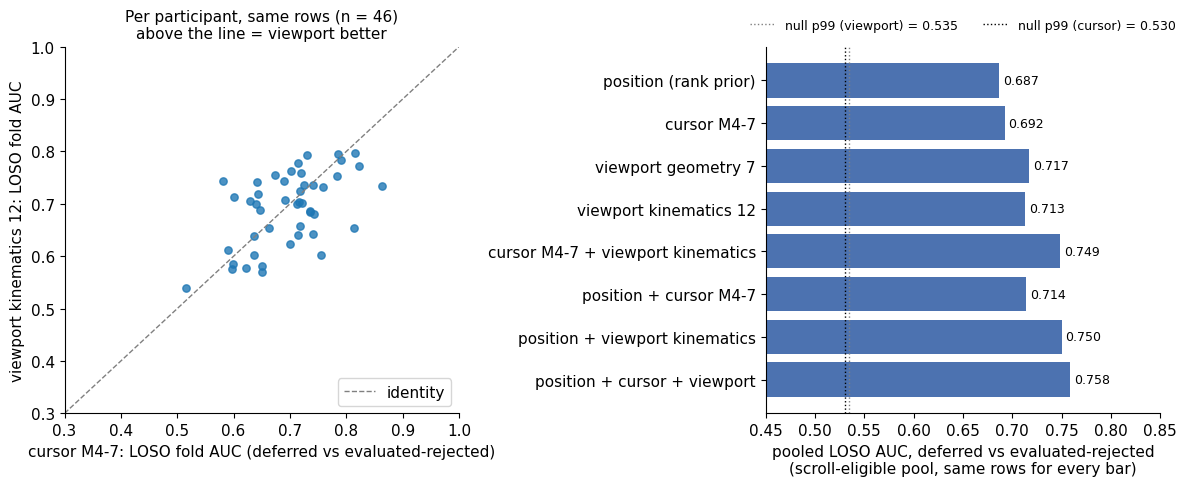

In [5]:
fa_c = fold_aucs(y, proba['cursor M4-7'], pid, pool)
fa_k = fold_aucs(y, proba['viewport kinematics 12'], pid, pool)
common = sorted(set(fa_c) & set(fa_k))
dc = np.array([fa_c[p] for p in common]); dk = np.array([fa_k[p] for p in common])
delta = dk - dc
w = stats.wilcoxon(dk, dc, alternative='greater')
n_pos = int((delta > 0).sum())
print(f"participants with both folds defined: {len(common)}")
print(f"viewport > cursor in {n_pos}/{len(common)} participants; median Δ = {np.median(delta):+.3f} AUC; "
      f"mean Δ = {delta.mean():+.3f}; Wilcoxon one-sided p = {w.pvalue:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(dc, dk, s=28, alpha=0.8)
lo, hi = 0.3, 1.0
ax[0].plot([lo, hi], [lo, hi], '--', color='grey', lw=1, label='identity')
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)
ax[0].set_xlabel('cursor M4-7: LOSO fold AUC (deferred vs evaluated-rejected)')
ax[0].set_ylabel('viewport kinematics 12: LOSO fold AUC')
ax[0].set_title(f'Per participant, same rows (n = {len(common)})\nabove the line = viewport better', fontsize=11)
ax[0].legend(loc='lower right')
names = [m[0] for m in MODELS]; vals = [res[n]['pooled_auc'] for n in names]
ax[1].barh(range(len(names)), vals, color='#4c72b0')
ax[1].axvline(null_kin['p99'], color='grey', ls=':', lw=1, label=f"null p99 (viewport) = {null_kin['p99']:.3f}")
ax[1].axvline(null_cursor['p99'], color='black', ls=':', lw=1, label=f"null p99 (cursor) = {null_cursor['p99']:.3f}")
ax[1].set_yticks(range(len(names))); ax[1].set_yticklabels(names); ax[1].invert_yaxis()
ax[1].set_xlim(0.45, 0.85); ax[1].set_xlabel('pooled LOSO AUC, deferred vs evaluated-rejected\n(scroll-eligible pool, same rows for every bar)')
for i, v in enumerate(vals):
    ax[1].text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9)
ax[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, fontsize=9, frameon=False)
plt.tight_layout(); plt.savefig('36_scroll_vs_cursor_deferred.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. The same carve on both sensors

Gaze dwell contains the return that defines the label; §4.3's carve showed
total dwell 0.807 → first-visit 0.514. Both motor sensors aggregate over the
whole pre-cutoff window too, which includes time after the first gaze visit.
Here the same first-visit cutoff (a gaze event, so a **diagnostic**, not a
deployable feature) is applied to an order-0 triplet from each sensor with
the same distance definition (vertical distance to the candidate centre;
residence/proximity dwell): what each sensor retains once post-first-visit time
is removed.

In [6]:
carve_pool = pool & fv_all
C3 = ['C_min_dist', 'C_mean_dist', 'C_prox_dwell_ms']
V3 = ['K_min_dist', 'K_mean_dist', 'K_residence_ms']
carve = {}
print(f"rows with a first-visit window for both sensors: {int(carve_pool.sum()):,}\n")
print(f"{'sensor, order-0 triplet':30s} {'full window':>12s} {'first visit':>12s} {'Δ':>7s}")
for sensor, feats in (('cursor (min, mean, prox dwell)', C3), ('viewport (min, mean, residence)', V3)):
    a, _ = loso_proba(records, feats, y, carve_pool); sa, _ = summarize(y, a, pid, carve_pool)
    b, _ = loso_proba(records, ['FV_' + f for f in feats], y, carve_pool); sb, _ = summarize(y, b, pid, carve_pool)
    carve[sensor] = (sa['pooled_auc'], sb['pooled_auc'])
    print(f"{sensor:30s} {sa['pooled_auc']:12.3f} {sb['pooled_auc']:12.3f} {sb['pooled_auc']-sa['pooled_auc']:+7.3f}")
for sensor, feats in (('cursor M4-7 (no carve possible from cache)', APPROACH_7), ('viewport kinematics 12', KIN)):
    a, _ = loso_proba(records, feats, y, carve_pool); sa, _ = summarize(y, a, pid, carve_pool)
    line = f"{sensor:30s} {sa['pooled_auc']:12.3f}"
    if feats is KIN:
        b, _ = loso_proba(records, ['FV_' + f for f in feats], y, carve_pool); sb, _ = summarize(y, b, pid, carve_pool)
        line += f" {sb['pooled_auc']:12.3f} {sb['pooled_auc']-sa['pooled_auc']:+7.3f}"; carve['viewport kinematics 12'] = (sa['pooled_auc'], sb['pooled_auc'])
    print(line)

rows with a first-visit window for both sensors: 5,123

sensor, order-0 triplet         full window  first visit       Δ


cursor (min, mean, prox dwell)        0.660        0.622  -0.037


viewport (min, mean, residence)        0.714        0.633  -0.082
cursor M4-7 (no carve possible from cache)        0.660


viewport kinematics 12                0.723        0.631  -0.092


## 5b. The producers' subset

`scroll_only_carve.py` and `scroll_kinematics.py` score their deferred tables
only on candidates whose first-visit scroll features exist, i.e. whose first
gaze visit ended after the cut scroll stream already had enough events. That is
`carve_pool` here, and it is selected by scroll timing relative to the first
look. Same three readouts on that subset.

In [7]:
sub = {}
print(f"{'model (producers\' subset)':30s} {'pooled':>7s} {'within-trial':>13s} {'n':>6s}")
for name, feats in (('cursor M4-7', APPROACH_7), ('viewport kinematics 12', KIN)):
    pr, _ = loso_proba(records, feats, y, carve_pool); s, _ = summarize(y, pr, pid, carve_pool)
    wt, _ = within_trial_auc(tid_arr, y, pr, carve_pool)
    sub[name] = (s['pooled_auc'], wt, fold_aucs(y, pr, pid, carve_pool))
    print(f"{name:30s} {s['pooled_auc']:7.3f} {wt:13.3f} {s['n_records']:6,d}")
fc, fk = sub['cursor M4-7'][2], sub['viewport kinematics 12'][2]
cm = sorted(set(fc) & set(fk)); d2 = np.array([fk[p] - fc[p] for p in cm])
w2 = stats.wilcoxon(d2, alternative='greater'); n_pos2 = int((d2 > 0).sum())
print(f"paired: viewport > cursor in {n_pos2}/{len(cm)} participants; median Δ {np.median(d2):+.3f}; "
      f"Wilcoxon one-sided p = {w2.pvalue:.2e}")

model (producers' subset)       pooled  within-trial      n


cursor M4-7                      0.660         0.713  5,123


viewport kinematics 12           0.723         0.699  5,123
paired: viewport > cursor in 29/46 participants; median Δ +0.036; Wilcoxon one-sided p = 3.07e-02


## 6. Single features, same rows

Which terms carry each sensor. Order-0 (where the pointer sat) vs order-1
(how it moved), for both sensors.

In [8]:
single = {}
for f in APPROACH_7 + KIN + GEO:
    a, _ = loso_proba(records, [f], y, pool); single[f] = summarize(y, a, pid, pool)[0]['pooled_auc']
order = {**{f: 'cursor' for f in APPROACH_7}, **{f: 'viewport order 0' for f in ORDER0},
         **{f: 'viewport order 1-mag' for f in ORDER1M}, **{f: 'viewport order 1-sign' for f in ORDER1S},
         **{f: 'viewport geometry' for f in GEO}}
for f, v in sorted(single.items(), key=lambda kv: -kv[1]):
    print(f"{v:.3f}  {order[f]:22s} {f}")
best_cursor = max(APPROACH_7, key=single.get); best_view = max(KIN, key=single.get)

0.682  cursor                 mean_dist
0.642  viewport order 1-sign  K_frac_closing
0.637  viewport order 0       K_total_pause_ms
0.632  viewport order 0       K_residence_ms
0.632  viewport geometry      G_vp_residence_ms
0.628  viewport order 0       K_max_pause_ms
0.596  cursor                 dwell_in_proximity_ms
0.596  viewport order 0       K_n_pauses
0.594  viewport order 1-mag   K_mean_approach_vel
0.581  cursor                 min_dist
0.579  viewport geometry      G_n_vp_entries
0.569  viewport order 0       K_mean_dist
0.569  viewport geometry      G_mean_vp_dist
0.569  viewport geometry      G_session_ms
0.550  cursor                 mean_approach_velocity
0.545  cursor                 frac_decreasing
0.542  cursor                 max_approach_velocity
0.525  viewport order 1-sign  K_dir_changes
0.520  viewport geometry      G_n_scroll_events
0.517  viewport geometry      G_vp_hwm_return
0.514  viewport order 1-mag   K_vel_at_closest
0.506  cursor                 directi

## 7. Reading

- On the full scroll-eligible pool the viewport's pooled advantage over the
  cursor (K2) is not a within-trial advantage (K2, concordance column) and not a
  per-participant one (K4). What the pooled gap carries is between-trial base
  rate: session-level scroll features predict which *trials* have a high
  deferred rate, which a per-result concordance cannot reward.
- The producers' subset (K10) is selected by scroll timing relative to the first
  gaze visit. Read its within-trial and paired columns before quoting its pooled
  gap.
- What survives the same-rows test: the two sensors are complementary (K2,
  combined row), the viewport adds more over position than the cursor does in
  pooled terms while neither adds within-trial (K6), and the first-visit carve
  removes more from the viewport than from the cursor (K7): viewport residence
  contains the return the way gaze dwell does.
- Position beats both motor sensors within-trial on this target by construction
  (the label is order-defined).
- Producer note (K9): `scroll_only_carve.py` computed its "full trial" geometry on
  the uncut scroll timeline when this notebook was written; it was window-matched
  the same day (schema 3). The change is inert because the evtrack log ends at the
  final click, so only the 500 ms buffer was ever exposed. The kinematics producer
  always cut correctly.

In [9]:
K = {}
r2 = res
K['K1'] = ('Scroll-eligible label-complete pool (≥3 scroll events before mousedown(final click) − 500 ms; approached, non-clicked, fixated)',
           f"n = {int(pool.sum()):,} rows ({int(pool.sum())/int(full_pool.sum()):.1%} of the {int(full_pool.sum()):,}-row label-complete pool), "
           f"{len(np.unique(pid[pool]))} participants, {len({t for t, m in zip(tid_arr, pool) if m}):,} trials, deferred rate {y[pool].mean():.3f}")
K['K2'] = ('Cursor M4-7 vs viewport kinematics 12, same rows, pooled LOSO AUC (within-trial concordance)',
           f"cursor {r2['cursor M4-7']['pooled_auc']:.3f} ({r2['cursor M4-7']['within_trial_auc']:.3f}) vs viewport {r2['viewport kinematics 12']['pooled_auc']:.3f} ({r2['viewport kinematics 12']['within_trial_auc']:.3f}); "
           f"viewport geometry 7 (window-matched) {r2['viewport geometry 7']['pooled_auc']:.3f}")
K['K3'] = ('Permutation null on the same rows (100 within-participant label shuffles), mean / p95 / p99',
           f"cursor {null_cursor['mean']:.3f} / {null_cursor['p95']:.3f} / {null_cursor['p99']:.3f}; viewport {null_kin['mean']:.3f} / {null_kin['p95']:.3f} / {null_kin['p99']:.3f}")
K['K4'] = ('Paired by participant, viewport − cursor fold AUC',
           f"viewport better in {n_pos}/{len(common)} participants; median Δ {np.median(delta):+.3f}, mean Δ {delta.mean():+.3f}; Wilcoxon one-sided p = {w.pvalue:.1e}")
K['K5'] = ('Cursor M4-7 on scroll-eligible vs not-eligible rows of the label-complete pool (trained on the full pool)',
           f"all {roc_auc_score(y[full_pool & np.isfinite(pr_full)], pr_full[full_pool & np.isfinite(pr_full)]):.3f}; eligible {auc_cursor_subset_readout:.3f} (refit within subset {auc_cursor_subset_refit:.3f}); "
           f"not eligible {roc_auc_score(y[inelig & np.isfinite(pr_full)], pr_full[inelig & np.isfinite(pr_full)]):.3f}; deferred rate eligible {y[elig].mean():.3f} vs not {y[inelig].mean():.3f}")
K['K6'] = ('Position as the order-defined baseline, and what each sensor adds over it (pooled / within-trial)',
           f"position {r2['position (rank prior)']['pooled_auc']:.3f} / {r2['position (rank prior)']['within_trial_auc']:.3f}; "
           f"+cursor {r2['position + cursor M4-7']['pooled_auc']:.3f} / {r2['position + cursor M4-7']['within_trial_auc']:.3f}; "
           f"+viewport {r2['position + viewport kinematics']['pooled_auc']:.3f} / {r2['position + viewport kinematics']['within_trial_auc']:.3f}; "
           f"+both {r2['position + cursor + viewport']['pooled_auc']:.3f} / {r2['position + cursor + viewport']['within_trial_auc']:.3f}")
K['K7'] = ('Same first-visit carve on both sensors, order-0 triplet (full window → first visit only; diagnostic cutoff = end of first gaze visit)',
           f"cursor {carve['cursor (min, mean, prox dwell)'][0]:.3f} → {carve['cursor (min, mean, prox dwell)'][1]:.3f}; "
           f"viewport {carve['viewport (min, mean, residence)'][0]:.3f} → {carve['viewport (min, mean, residence)'][1]:.3f}; "
           f"viewport kinematics 12 {carve['viewport kinematics 12'][0]:.3f} → {carve['viewport kinematics 12'][1]:.3f}; n = {int(carve_pool.sum()):,}")
K['K8'] = ('Best single feature per sensor, same rows',
           f"cursor `{best_cursor}` {single[best_cursor]:.3f}; viewport `{best_view}` {single[best_view]:.3f}")
K['K10'] = ('Producers\' subset (first-visit scroll features exist): cursor vs viewport kinematics, pooled (within-trial); paired by participant',
           f"cursor {sub['cursor M4-7'][0]:.3f} ({sub['cursor M4-7'][1]:.3f}) vs viewport {sub['viewport kinematics 12'][0]:.3f} ({sub['viewport kinematics 12'][1]:.3f}); "
           f"viewport better in {n_pos2}/{len(cm)} participants, median Δ {np.median(d2):+.3f}, Wilcoxon one-sided p = {w2.pvalue:.1e}; n = {int(carve_pool.sum()):,}")
K['K9'] = ('Producer window discrepancy', 'scroll_only_carve.py "full trial" geometry is computed on the uncut scroll timeline; '
           f"window-matched here it scores {r2['viewport geometry 7']['pooled_auc']:.3f} (producer, uncut: 0.715 on 5,255 rows)")
print('| ID | Claim | Value |\n|---|---|---|')
for k, (claim, val) in K.items():
    print(f'| **{k}** | {claim} | {val} |')

| ID | Claim | Value |
|---|---|---|
| **K1** | Scroll-eligible label-complete pool (≥3 scroll events before mousedown(final click) − 500 ms; approached, non-clicked, fixated) | n = 8,653 rows (93.4% of the 9,269-row label-complete pool), 46 participants, 2,075 trials, deferred rate 0.735 |
| **K2** | Cursor M4-7 vs viewport kinematics 12, same rows, pooled LOSO AUC (within-trial concordance) | cursor 0.692 (0.710) vs viewport 0.713 (0.684); viewport geometry 7 (window-matched) 0.717 |
| **K3** | Permutation null on the same rows (100 within-participant label shuffles), mean / p95 / p99 | cursor 0.509 / 0.524 / 0.530; viewport 0.518 / 0.532 / 0.535 |
| **K4** | Paired by participant, viewport − cursor fold AUC | viewport better in 20/46 participants; median Δ -0.011, mean Δ -0.006; Wilcoxon one-sided p = 7.2e-01 |
| **K5** | Cursor M4-7 on scroll-eligible vs not-eligible rows of the label-complete pool (trained on the full pool) | all 0.680; eligible 0.692 (refit within subset 0.692); 